In [269]:
import numpy as np
import matplotlib.pyplot as plt

In [270]:
# Dimensions
n, m = 4, 6
eta = 0.01           # learning rate for B
eta_lambda = 0.1     # learning rate for lambda
P_total = 2.5
max_iters = 1000
tol = 1e-6
snr=50


In [271]:
# --- Random initialization ---
np.random.seed(0)
H = np.random.randn(n, m)
x = np.random.uniform(-1, 1, size=(m, 1))  # Uniform distribution between -1 and 1
z = np.random.randn(n, 1)
a = np.ones((m, 1))  # All ones

In [272]:
 # Constant
aTx = float(a.T @ x)
lambda_reg = 1.0  # initialize Lagrange multiplier
B = np.random.randn(n, m)

for iter in range(max_iters):
    BH = B * H
    y = BH @ x + z - a.T@x


    # Frobenius norm squared of B_new
    frob_sq = np.sum(B_new ** 2)

    # Update lambda using projected gradient ascent (KKT-style)
    lambda_reg += eta_lambda * (frob_sq )
    lambda_reg = max(0, lambda_reg)



    # Gradient of Lagrangian w.r.t. B
    grad = 2 * (y @ x.T) * H + 2 * lambda_reg * B
    # Update B
    B_new = B - eta * grad
    # print( np.sum(B_new * B_new,axis=0)<= P_total)

    # Check convergence
    if np.linalg.norm(B_new - B, ord='fro') < tol:
        print(f"Converged at iteration {iter}")
        break

    B = B_new

# Final values
print("Optimized B:")
print(B)
print("Final lambda:", lambda_reg)


Optimized B:
[[ 0.00343463 -0.00121592  0.02091238 -0.01170474 -0.00929534  0.00507412]
 [ 0.00319287  0.00079383 -0.00380667 -0.00370175 -0.00123747 -0.0130328 ]
 [-0.00282611  0.00070516 -0.01808844  0.00332413  0.01418338 -0.00203164]
 [-0.0022371  -0.00952488  0.20020058  0.0125298   0.01579077 -0.01414239]]
Final lambda: 15.473825966477964


In [ ]:
# Function to compute MMSE for one round
def compute_mmse(B, H, x, a, snr_db):
    n = B.shape[0]  #number of time slots
    BH = B * H
    signal = BH @ x
    P_signal = np.sum(x**2) / n
    snr_linear = 10 ** (snr_db / 10)
    P_noise = P_signal / snr_linear
    z = np.random.normal(0, np.sqrt(P_noise), size=(n, 1))
    y = signal + z
    target = a.T @ x
    mmse = np.sum((y - target) ** 2) / n
    return mmse


snrs = np.arange(0, snr+1)
mmse_vals = []
for snr_db in snrs:
    mmse_list = [compute_mmse(B, H, x, a, snr_db) for _ in range(max_iters)]
    mmse_vals.append(np.mean(mmse_list))


print("mse",mmse_vals)

mse [0.42567156289975344, 0.37824708306075727, 0.33347311231815047, 0.3014889018780658, 0.2800402896650071, 0.25390991490187714, 0.23115872564462076, 0.21774183859227883, 0.20524226368000337, 0.19902040098717624, 0.19211945488955257, 0.18646633737720264, 0.1794125915463738, 0.17952753992189965, 0.1750283510013088, 0.17022718185615662, 0.17071546968178625, 0.16928900210821046, 0.1679571799957638, 0.16726015085296914, 0.16642078809498517, 0.1677218950306852, 0.16570315154182708, 0.16578572203808034, 0.16500541439174912, 0.16525361802965732, 0.16443258646168443, 0.163983678717663, 0.16408295259964178, 0.16424907543243836, 0.16385713178406694, 0.16397129185722917, 0.1643723230173309, 0.16409115388248502, 0.16376578051867102, 0.16395020092270784, 0.16386542610385277, 0.1636729037734595, 0.16386411608223564, 0.16372377228363655, 0.16378012774732703, 0.16379991051759415, 0.16364503927873864, 0.16374947132439344, 0.16371958062526912, 0.16367182258353813, 0.1637364891204148, 0.16369160935143254

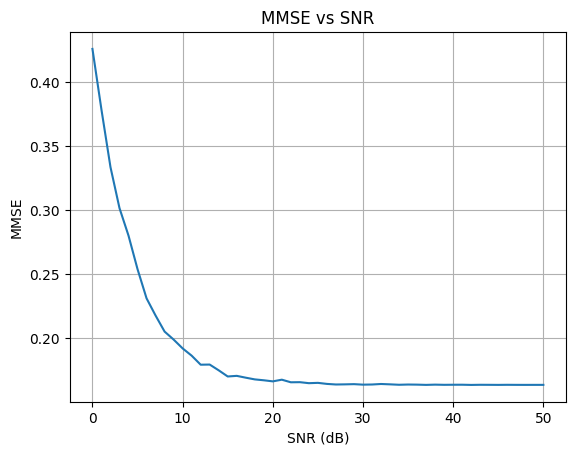

In [274]:
# Plot

plt.plot(snrs, mmse_vals)
plt.xlabel('SNR (dB)')
plt.ylabel('MMSE')
plt.title('MMSE vs SNR')
plt.grid(True)
plt.show()